# 15 — Orthogonal analogy types: characterize lens-Phi vs trajectory-space

v6 dominated v1 on Syracuse-shift (mean rank 0.2 vs 37.0) — but only because
d = T_syr(c) makes orbit(d) literally a suffix of orbit(c). v6's win was
structural, not general.

This notebook probes three analogy categories that test *different* structural
relations:

1. **Syracuse-shift** `(a, T_syr(a), c, T_syr(c))` — orbit-overlap relation.
   v6's home turf.
2. **Tripling** `(a, 3a, c, 3c)` — pure arithmetic. 3a is generally NOT in a's
   orbit (orbits don't include arbitrary multiples). Neither method designed for it.
3. **Set-mate** — triples of consecutive Set_3 members, shifted by index. The
   relation is "shift the window in Set_3 ordering." Pure dropping-class
   structure. Lens-Phi's home turf (drop_class lens captures this).

Predictions: v6 wins (1), v1 wins (3), (2) is uncertain.


In [1]:
import sys
sys.path.insert(0, '..')
import random
import numpy as np
import matplotlib.pyplot as plt

from collatz.embeddings import Concept, trajectory_analogy
from collatz.embeddings.distance import analogy as lens_analogy
from collatz.embeddings.iteration import _syr_step
from collatz.utils import members_of_class
from collatz.dropping import dropping_set


## 1. Build the three quad categories


In [2]:
N_QUADS = 30
N_DISTRACTORS = 100

random.seed(42)

# (1) Syracuse-shift quads
def shift(c: Concept) -> Concept:
    return Concept(c.name + "*", tuple(_syr_step(x) for x in c.vec))

quads_syr = []
for i in range(N_QUADS):
    scale = random.choice([20, 100, 500, 2000])
    a_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    c_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    a = Concept(f"sA{i}", a_start)
    c = Concept(f"sC{i}", c_start)
    quads_syr.append((a, shift(a), c, shift(c)))

# (2) Tripling quads
def triple(c: Concept) -> Concept:
    return Concept(c.name + "x3", tuple(3*x for x in c.vec))

quads_tri = []
for i in range(N_QUADS):
    scale = random.choice([20, 100, 500])  # smaller; tripling grows fast
    a_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    c_start = tuple(random.randrange(2, scale) | 1 for _ in range(3))
    a = Concept(f"tA{i}", a_start)
    c = Concept(f"tC{i}", c_start)
    quads_tri.append((a, triple(a), c, triple(c)))

# (3) Set-mate quads: consecutive Set_3 windows
set3 = members_of_class(dropping_set, 3, 5000)
print(f"Set_3 has {len(set3)} members up to 5000.")

quads_set = []
for i in range(N_QUADS):
    # pick two random window starting positions far apart
    pos_a = random.randrange(0, len(set3) - 4)
    pos_c = random.randrange(0, len(set3) - 4)
    a = Concept(f"setA{i}", tuple(set3[pos_a:pos_a + 3]))
    b = Concept(f"setB{i}", tuple(set3[pos_a + 1:pos_a + 4]))
    c = Concept(f"setC{i}", tuple(set3[pos_c:pos_c + 3]))
    d = Concept(f"setD{i}", tuple(set3[pos_c + 1:pos_c + 4]))
    quads_set.append((a, b, c, d))

# Distractor pools (one per category, sized to overlap appropriately with each)
random.seed(99)
distractors_general = [
    Concept(f"D{i}", tuple(random.randrange(2, 5000) | 1 for _ in range(3)))
    for i in range(N_DISTRACTORS)
]
distractors_set3 = []
for i in range(N_DISTRACTORS):
    pos = random.randrange(0, len(set3) - 3)
    distractors_set3.append(Concept(f"DS{i}", tuple(set3[pos:pos + 3])))

print(f"Built {len(quads_syr)} syracuse, {len(quads_tri)} tripling, {len(quads_set)} set-mate quads.")
print(f"General distractor pool: {len(distractors_general)}")
print(f"Set_3 distractor pool:   {len(distractors_set3)}")


Set_3 has 1249 members up to 5000.
Built 30 syracuse, 30 tripling, 30 set-mate quads.
General distractor pool: 100
Set_3 distractor pool:   100


## 2. Helper: rank expected d in a pool


In [3]:
def rank_with(method, quads, distractors):
    """Run analogy method on each quad against (distractors + expected_d). Return ranks."""
    ranks = []
    for a, b, c, expected_d in quads:
        pool = distractors + [expected_d]
        ranked = method(a, b, c, pool)
        rank = next(i for i, (cand, _) in enumerate(ranked) if cand is expected_d)
        ranks.append(rank)
    return np.array(ranks)


## 3. Run all three categories with both methods


In [4]:
results = {}

categories = [
    ("syracuse-shift", quads_syr, distractors_general),
    ("tripling",       quads_tri, distractors_general),
    ("set-mate",       quads_set, distractors_set3),  # set-mate uses Set_3 distractors so the test is hard
]

for cat_name, quads, dists in categories:
    pool_size = len(dists) + 1
    ranks_v1 = rank_with(lens_analogy, quads, dists)
    ranks_v6 = rank_with(trajectory_analogy, quads, dists)
    results[cat_name] = {
        "pool_size": pool_size,
        "chance":    pool_size / 2,
        "v1":        ranks_v1,
        "v6":        ranks_v6,
    }
    print(f"\n=== {cat_name} (pool size {pool_size}, chance baseline {pool_size/2:.0f}) ===")
    print(f"{'method':<22} {'mean':>8} {'median':>8} {'top-5':>6} {'top-10':>7}")
    for label, ranks in [("v1 lens-Phi", ranks_v1), ("v6 trajectory_analogy", ranks_v6)]:
        print(f"{label:<22} {ranks.mean():>8.1f} {np.median(ranks):>8.0f} {(ranks < 5).sum():>6} {(ranks < 10).sum():>7}")



=== syracuse-shift (pool size 101, chance baseline 50) ===
method                     mean   median  top-5  top-10
v1 lens-Phi                49.9       54      2       4
v6 trajectory_analogy       0.1        0     30      30



=== tripling (pool size 101, chance baseline 50) ===
method                     mean   median  top-5  top-10
v1 lens-Phi                66.2       74      1       1
v6 trajectory_analogy      43.2       32      6       8



=== set-mate (pool size 101, chance baseline 50) ===
method                     mean   median  top-5  top-10
v1 lens-Phi                56.4       60      0       0
v6 trajectory_analogy      58.4       62      1       2


## 4. Bar chart — mean rank per (category, method)


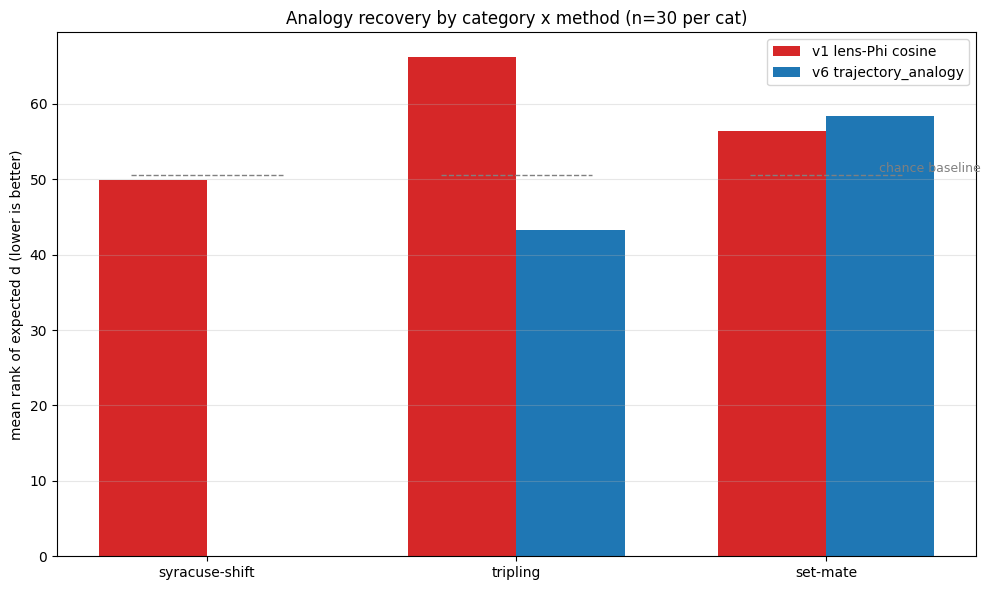

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
cats = list(results.keys())
x = np.arange(len(cats))
w = 0.35

means_v1 = [results[c]["v1"].mean() for c in cats]
means_v6 = [results[c]["v6"].mean() for c in cats]
chances = [results[c]["chance"] for c in cats]

ax.bar(x - w/2, means_v1, w, label="v1 lens-Phi cosine", color="tab:red")
ax.bar(x + w/2, means_v6, w, label="v6 trajectory_analogy", color="tab:blue")
for i, c in enumerate(chances):
    ax.hlines(c, x[i] - w*0.7, x[i] + w*0.7, colors="gray", linestyles="--", linewidth=1)
ax.text(len(cats) - 0.5, max(chances), "chance baseline", color="gray", fontsize=9, va="bottom", ha="right")

ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylabel("mean rank of expected d (lower is better)")
ax.set_title("Analogy recovery by category x method (n=30 per cat)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 5. Sanity check — what's a v1 lens-Phi answer in the set-mate case?

Lens-Phi *should* win set-mate because drop_class is the explicit category. If v1
loses, that's surprising and informative.


In [6]:
# Look at one set-mate quad in detail.
a, b, c, expected_d = quads_set[0]
pool = distractors_set3 + [expected_d]
ranked = lens_analogy(a, b, c, pool)
print(f"set-mate example: {a.name}({a.vec}) -> {b.name}({b.vec}) :: {c.name}({c.vec}) -> ?")
print(f"\nTop 5 candidates by lens-Phi:")
for i, (cand, score) in enumerate(ranked[:5]):
    flag = " <-- expected" if cand is expected_d else ""
    print(f"  rank {i}: {cand.name}({cand.vec}) score={score:+.3f}{flag}")
print(f"\nExpected d rank: {next(i for i, (cand, _) in enumerate(ranked) if cand is expected_d)}")


set-mate example: setA0((1073, 1077, 1081)) -> setB0((1077, 1081, 1085)) :: setC0((2149, 2153, 2157)) -> ?

Top 5 candidates by lens-Phi:
  rank 0: DS45((3505, 3509, 3513)) score=+0.730
  rank 1: DS21((3641, 3645, 3649)) score=+0.704
  rank 2: DS26((3641, 3645, 3649)) score=+0.704
  rank 3: DS98((1913, 1917, 1921)) score=+0.704
  rank 4: DS2((4985, 4989, 4993)) score=+0.677

Expected d rank: 30


## 6. Verdict template

Read the bar chart and table:

- **Each method wins its home turf** (v1 set-mate, v6 syracuse) -> embeddings are
  complementary; pick by relation type. Hybrid (option β from the menu) becomes
  attractive.
- **v6 wins everywhere** -> trajectory-space is genuinely better; lens-Phi loses
  even when drop_class is the explicit relation. Surprising; would mean orbit overlap
  encodes class membership implicitly.
- **v1 wins set-mate but tripling is a wash for both** -> tripling has no
  embedding-friendly structure; both methods are coincidentally near chance.
- **v1 wins the static categories, v6 wins only Syracuse** -> v6 is narrower than
  hoped; it captures orbit-suffix structure but not class structure. Lens-Phi has
  a real role.
